# Cultura Database — Annotation Analysis

This notebook analyses the accuracy annotations from the Cultura Database linkage procedure.  
The linkage connects Wikidata individuals to Cliopatria polities via a two-phase approach:

1. **Polygon matching** — geospatial point-in-polygon using death city / birth city / nationality coordinates  
2. **URL matching** — Wikipedia URL comparison for nationality / birth city / death city  

Annotated records are stratified by **method x origin**, **macro-region**, **era**, and **notability (identifiers count)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 100)

## 1. Load and clean data

In [2]:
csv_path = Path("Cultura Database accuracy testing - Sheet1.csv")
df = pd.read_csv(csv_path)

print(f"Total annotated records: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Total annotated records: 500
Columns: ['wikidata_id', 'name_en', 'wikipedia_url', 'polity_name', 'method', 'origin', 'matched_entity', 'matching_url', 'url_origin', 'macro_region', 'impact_date', 'identifiers_count', 'sampling_stratum', 'rating', 'comments']


,wikidata_id,name_en,wikipedia_url,polity_name,method,origin,matched_entity,matching_url,url_origin,macro_region,impact_date,identifiers_count,sampling_stratum,rating,comments
0,Q463364,Bion of Smyrna,https://en.wikipedia.org/wiki/Bion_of_Smyrna,Kingdom of Pontus,polygon,nationality,Kingdom of Pergamon,NaN,NaN,Ancient Mediterranean,-84.0,66,"polygon/nationality, Ancient Mediterranean, Ancient, High",0.0,should be Kingdom of Pergamon
1,Q110443498,NaN,https://www.wikidata.org/wiki/Q110443498,Kingdom of Armenia,polygon,nationality,Kingdom of Armenia,NaN,NaN,Ancient Mediterranean,-100.0,0,"polygon/nationality, Ancient Mediterranean, Ancient, Low",1.0,NaN
2,Q1120124,Elidyr Llydanwyn,https://www.wikidata.org/wiki/Q1120124,Brythons,polygon,nationality,Wales,NaN,NaN,Ancient Mediterranean,485.0,5,"polygon/nationality, Ancient Mediterranean, Ancient, Medium",1.0,NaN


In [3]:
# Parse the sampling_stratum column to extract individual dimensions
# Format: "method/origin, macro_region, era, notability"
strata = df["sampling_stratum"].str.split(", ", expand=True)
strata.columns = ["stratum_method_origin", "stratum_region", "stratum_era", "stratum_notability"]

df = pd.concat([df, strata], axis=1)

# Normalise method column
df["method_group"] = df["method"].replace({"url": "url", "url_fallback": "url_fallback", "polygon": "polygon"})

# Remove url_fallback records (no impact date, different validation regime)
df = df[df["method_group"] != "url_fallback"].copy()

# Remove "Unknown" era records (artefact of missing impact dates)
df = df[df["stratum_era"] != "Unknown"].copy()

# Convert rating to numeric (some may be empty)
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")

print(f"Records after filtering: {len(df)}")
print(f"Records with a rating: {df['rating'].notna().sum()}")
print(f"Records without a rating: {df['rating'].isna().sum()}")
print()
print("Method distribution:")
print(df["method_group"].value_counts())

Records after filtering: 285
Records with a rating: 284
Records without a rating: 1

Method distribution:
method_group
polygon    220
url         65
Name: count, dtype: int64


## 2. Overall accuracy

In [4]:
rated = df.dropna(subset=["rating"]).copy()
total_rated = len(rated)
correct = (rated["rating"] == 1).sum()
incorrect = (rated["rating"] == 0).sum()

print(f"Total rated: {total_rated}")
print(f"Correct (1):  {correct}  ({correct/total_rated*100:.1f}%)")
print(f"Incorrect (0): {incorrect}  ({incorrect/total_rated*100:.1f}%)")
print(f"Overall accuracy: {correct/total_rated*100:.1f}%")

Total rated: 284
Correct (1):  239  (84.2%)
Incorrect (0): 45  (15.8%)
Overall accuracy: 84.2%


## 3. Accuracy by matching method (polygon / url)

In [5]:
def accuracy_table(group_col, data=None):
    """Compute accuracy stats grouped by a column."""
    if data is None:
        data = rated
    grp = data.groupby(group_col)["rating"]
    result = pd.DataFrame({
        "n": grp.count(),
        "correct": grp.sum().astype(int),
    })
    result["incorrect"] = result["n"] - result["correct"]
    result["accuracy_%"] = (result["correct"] / result["n"] * 100).round(1)
    return result.sort_index()

method_acc = accuracy_table("method_group")
print("Accuracy by matching method:")
method_acc

Accuracy by matching method:


,n,correct,incorrect,accuracy_%
method_group,,,,
polygon,220,181,39,82.3
url,64,58,6,90.6


In [6]:
origin_acc = accuracy_table("origin")
print("Accuracy by origin (location source):")
origin_acc

Accuracy by origin (location source):


,n,correct,incorrect,accuracy_%
origin,,,,
birthplace,80,70,10,87.5
deathplace,55,42,13,76.4
nationality,149,127,22,85.2


In [7]:
method_origin_acc = accuracy_table(["method_group", "origin"])
print("Accuracy by method × origin:")
method_origin_acc

Accuracy by method × origin:


n  correct  incorrect  accuracy_%
method_group origin                                          
polygon      birthplace    60       52          8        86.7
             deathplace    40       31          9        77.5
             nationality  120       98         22        81.7
url          birthplace    20       18          2        90.0
             deathplace    15       11          4        73.3
             nationality   29       29          0       100.0

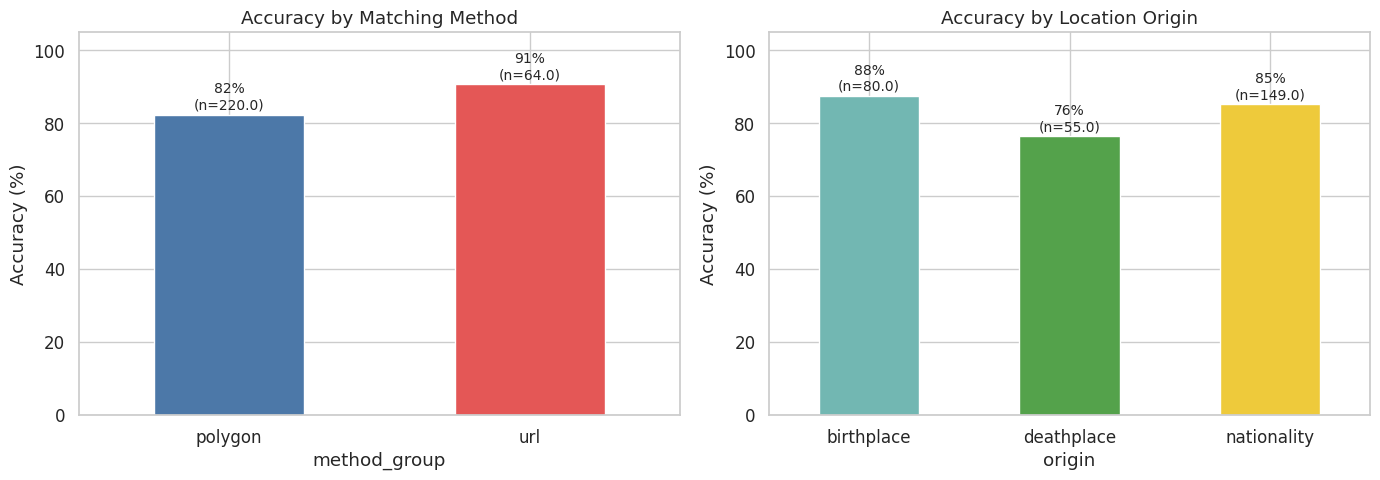

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: accuracy by method
ax = axes[0]
method_acc["accuracy_%"].plot.bar(ax=ax, color=["#4C78A8", "#E45756", "#F58518"])
ax.set_title("Accuracy by Matching Method")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
for i, (idx, row) in enumerate(method_acc.iterrows()):
    ax.text(i, row["accuracy_%"] + 1.5, f"{row['accuracy_%']:.0f}%\n(n={row['n']})", ha="center", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Bar chart: accuracy by origin
ax = axes[1]
origin_acc["accuracy_%"].plot.bar(ax=ax, color=["#72B7B2", "#54A24B", "#EECA3B"])
ax.set_title("Accuracy by Location Origin")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 105)
for i, (idx, row) in enumerate(origin_acc.iterrows()):
    ax.text(i, row["accuracy_%"] + 1.5, f"{row['accuracy_%']:.0f}%\n(n={row['n']})", ha="center", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 4. Accuracy by sampling stratum dimensions

In [9]:
region_acc = accuracy_table("stratum_region")
print("Accuracy by macro-region:")
region_acc

Accuracy by macro-region:


,n,correct,incorrect,accuracy_%
stratum_region,,,,
Ancient Mediterranean,16,14,2,87.5
Asia,70,59,11,84.3
Eastern Europe,80,66,14,82.5
Latin America,33,30,3,90.9
Middle-East and Africa (MENA),28,22,6,78.6
North America,9,9,0,100.0
Oceania,7,5,2,71.4
Sub-Saharan Africa,15,13,2,86.7
Western Europe,26,21,5,80.8


In [10]:
era_order = ["Ancient", "Medieval", "Early Modern", "Modern", "Contemporary"]
era_acc = accuracy_table("stratum_era")
era_acc = era_acc.reindex([e for e in era_order if e in era_acc.index])
print("Accuracy by historical era:")
era_acc

Accuracy by historical era:


,n,correct,incorrect,accuracy_%
stratum_era,,,,
Ancient,56,43,13,76.8
Medieval,44,34,10,77.3
Early Modern,50,45,5,90.0
Modern,56,49,7,87.5
Contemporary,78,68,10,87.2


In [11]:
notability_order = ["Low", "Medium", "High"]
notability_acc = accuracy_table("stratum_notability")
notability_acc = notability_acc.reindex([n for n in notability_order if n in notability_acc.index])
print("Accuracy by notability stratum:")
notability_acc

Accuracy by notability stratum:


,n,correct,incorrect,accuracy_%
stratum_notability,,,,
Low,104,91,13,87.5
Medium,94,81,13,86.2
High,86,67,19,77.9


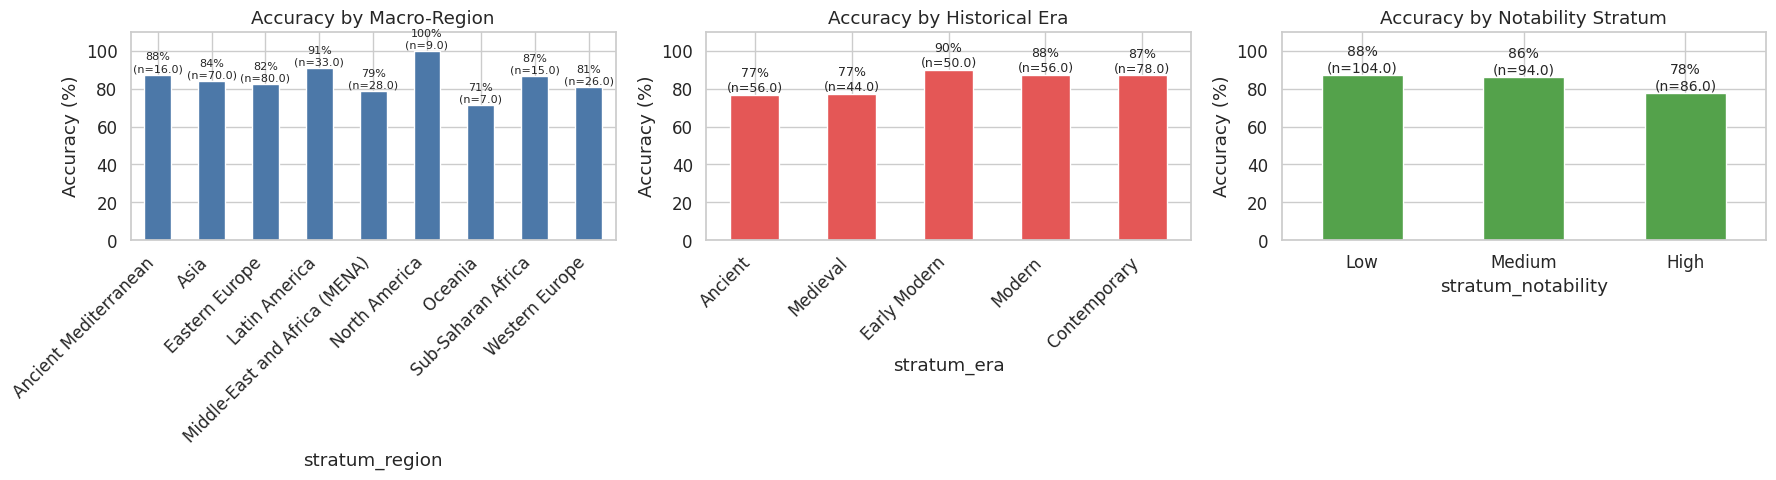

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Region
ax = axes[0]
region_acc["accuracy_%"].plot.bar(ax=ax, color="#4C78A8")
ax.set_title("Accuracy by Macro-Region")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
for i, (idx, row) in enumerate(region_acc.iterrows()):
    ax.text(i, row["accuracy_%"] + 1.5, f"{row['accuracy_%']:.0f}%\n(n={row['n']})", ha="center", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Era
ax = axes[1]
era_acc["accuracy_%"].plot.bar(ax=ax, color="#E45756")
ax.set_title("Accuracy by Historical Era")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
for i, (idx, row) in enumerate(era_acc.iterrows()):
    ax.text(i, row["accuracy_%"] + 1.5, f"{row['accuracy_%']:.0f}%\n(n={row['n']})", ha="center", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Notability
ax = axes[2]
notability_acc["accuracy_%"].plot.bar(ax=ax, color="#54A24B")
ax.set_title("Accuracy by Notability Stratum")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 110)
for i, (idx, row) in enumerate(notability_acc.iterrows()):
    ax.text(i, row["accuracy_%"] + 1.5, f"{row['accuracy_%']:.0f}%\n(n={row['n']})", ha="center", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

## 5. Cross-tabulations: method × stratum dimensions

In [13]:
cross_method_era = accuracy_table(["method_group", "stratum_era"])
print("Accuracy by method × era:")
cross_method_era

Accuracy by method × era:


n  correct  incorrect  accuracy_%
method_group stratum_era                                     
polygon      Ancient       46       33         13        71.7
             Contemporary  59       52          7        88.1
             Early Modern  42       37          5        88.1
             Medieval      33       24          9        72.7
             Modern        40       35          5        87.5
url          Ancient       10       10          0       100.0
             Contemporary  19       16          3        84.2
             Early Modern   8        8          0       100.0
             Medieval      11       10          1        90.9
             Modern        16       14          2        87.5

In [14]:
cross_method_region = accuracy_table(["method_group", "stratum_region"])
print("Accuracy by method × region:")
cross_method_region

Accuracy by method × region:


n  correct  incorrect  accuracy_%
method_group stratum_region                                                   
polygon      Ancient Mediterranean           9        7          2        77.8
             Asia                           48       39          9        81.2
             Eastern Europe                 47       37         10        78.7
             Latin America                  31       28          3        90.3
             Middle-East and Africa (MENA)  28       22          6        78.6
             North America                   9        9          0       100.0
             Oceania                         7        5          2        71.4
             Sub-Saharan Africa             15       13          2        86.7
             Western Europe                 26       21          5        80.8
url          Ancient Mediterranean           7        7          0       100.0
             Asia                           22       20          2        90.9
             Eastern Europe                 33       29          4        87.9
             Latin America                   2        2          0       100.0

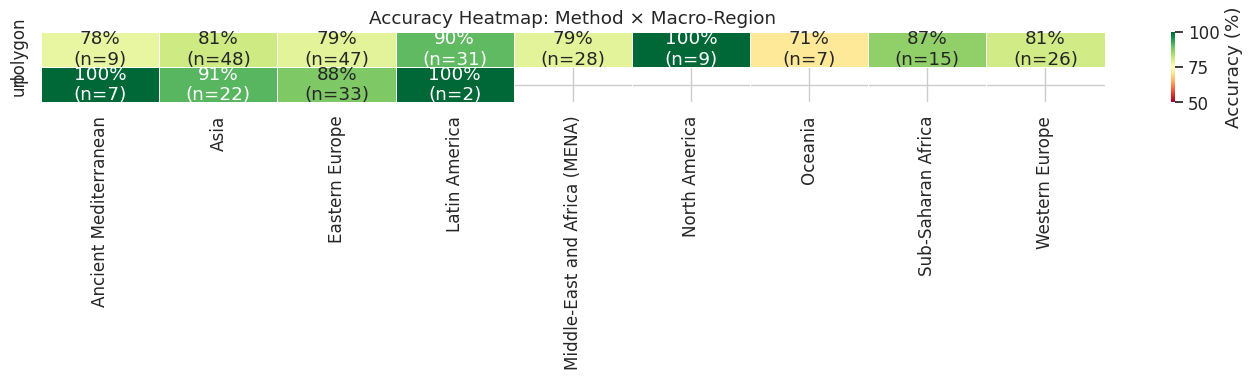

In [15]:
# Pivot for heatmap: method × region
pivot_mr = cross_method_region.reset_index()
pivot_mr = pivot_mr.pivot(index="method_group", columns="stratum_region", values="accuracy_%")

# Also get sample counts
pivot_n = cross_method_region.reset_index()
pivot_n = pivot_n.pivot(index="method_group", columns="stratum_region", values="n")

fig, ax = plt.subplots(figsize=(14, 4))
# Build annotation labels with accuracy + n
annot = pivot_mr.copy().astype(str)
for r in annot.index:
    for c in annot.columns:
        acc_val = pivot_mr.loc[r, c] if pd.notna(pivot_mr.loc[r, c]) else np.nan
        n_val = pivot_n.loc[r, c] if pd.notna(pivot_n.loc[r, c]) else np.nan
        if pd.notna(acc_val):
            annot.loc[r, c] = f"{acc_val:.0f}%\n(n={int(n_val)})"
        else:
            annot.loc[r, c] = ""

sns.heatmap(pivot_mr, annot=annot, fmt="", cmap="RdYlGn", vmin=50, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Accuracy (%)"})
ax.set_title("Accuracy Heatmap: Method × Macro-Region")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

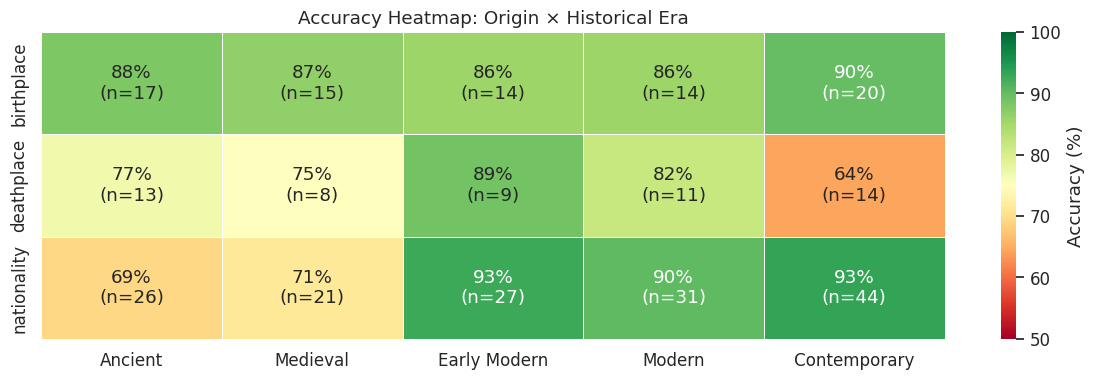

In [16]:
# Heatmap: origin × era
cross_origin_era = accuracy_table(["origin", "stratum_era"])
pivot_oe = cross_origin_era.reset_index().pivot(index="origin", columns="stratum_era", values="accuracy_%")
pivot_oe_n = cross_origin_era.reset_index().pivot(index="origin", columns="stratum_era", values="n")

# Reorder eras
era_cols = [e for e in era_order if e in pivot_oe.columns]
pivot_oe = pivot_oe[era_cols]
pivot_oe_n = pivot_oe_n[era_cols]

annot2 = pivot_oe.copy().astype(str)
for r in annot2.index:
    for c in annot2.columns:
        acc_val = pivot_oe.loc[r, c] if pd.notna(pivot_oe.loc[r, c]) else np.nan
        n_val = pivot_oe_n.loc[r, c] if pd.notna(pivot_oe_n.loc[r, c]) else np.nan
        if pd.notna(acc_val):
            annot2.loc[r, c] = f"{acc_val:.0f}%\n(n={int(n_val)})"
        else:
            annot2.loc[r, c] = ""

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(pivot_oe, annot=annot2, fmt="", cmap="RdYlGn", vmin=50, vmax=100,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Accuracy (%)"})
ax.set_title("Accuracy Heatmap: Origin × Historical Era")
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

## 6. Error analysis

In [17]:
errors = rated[rated["rating"] == 0].copy()
print(f"Total incorrect annotations: {len(errors)}")
print()
print("Errors by method:")
print(errors["method_group"].value_counts())
print()
print("Errors by origin:")
print(errors["origin"].value_counts())
print()
print("Errors by region:")
print(errors["stratum_region"].value_counts())
print()
print("Errors by era:")
print(errors["stratum_era"].value_counts())

Total incorrect annotations: 45

Errors by method:
method_group
polygon    39
url         6
Name: count, dtype: int64

Errors by origin:
origin
nationality    22
deathplace     13
birthplace     10
Name: count, dtype: int64

Errors by region:
stratum_region
Eastern Europe                   14
Asia                             11
Middle-East and Africa (MENA)     6
Western Europe                    5
Latin America                     3
Ancient Mediterranean             2
Oceania                           2
Sub-Saharan Africa                2
Name: count, dtype: int64

Errors by era:
stratum_era
Ancient         13
Contemporary    10
Medieval        10
Modern           7
Early Modern     5
Name: count, dtype: int64


In [18]:
# Show error cases with comments
error_display = errors[["name_en", "polity_name", "method_group", "origin",
                        "matched_entity", "stratum_region", "stratum_era", "comments"]].copy()
print(f"Incorrect cases ({len(error_display)}):")
error_display

Incorrect cases (45):


,name_en,polity_name,method_group,origin,matched_entity,stratum_region,stratum_era,comments
0,Bion of Smyrna,Kingdom of Pontus,polygon,nationality,Kingdom of Pergamon,Ancient Mediterranean,Ancient,should be Kingdom of Pergamon
3,Tao Yuanming,Western Jin,polygon,nationality,Eastern Jin dynasty,Asia,Ancient,there is no eastern jin in the databse
5,Liao Hua,Cao Wei,polygon,nationality,Eastern Han,Asia,Ancient,"some individuals have 2 nationalities, here he has 12 nationalities and it i..."
6,Park Tae-won,Empire of Japan,polygon,nationality,North Korea,Asia,Contemporary,"transition, at 35 he ws active in the emprie of Japan"
10,Gu Yanyi,Ming Dynasty,polygon,nationality,Qing dynasty,Asia,Early Modern,"they say Qing but hen he was 35 yo, the qing dynasty did not exist"
18,Peter the Iberian,Caucasian Iberia,polygon,nationality,Kingdom of Iberia,Eastern Europe,Ancient,he comes form the Kingdom of Iberia but was active mainly in the estern roma...
19,Vardanoysch Mamikonian,Sasanian Empire,polygon,nationality,Sasanian Armenia,Eastern Europe,Ancient,could be Sasanian Empire or Kingdom of Armenia
32,Zacharias Hildebrandt,Habsburg Monarchy,polygon,nationality,Kingdom of Bohemia,Eastern Europe,Modern,he moved country and was german
42,Sahure,Early Dynastic Period of Egypt,polygon,nationality,Ancient Egypt,Middle-East and Africa (MENA),Ancient,"the impact date does not really make sense, becasue we know the precise deat..."
47,Neemaat Abdulnasser,United Arab Republic,polygon,nationality,Egypt,Middle-East and Africa (MENA),Contemporary,mistake in cliopattria


## 7. Summary statistics table (for paper)

In [19]:
# Build a combined summary table
summary_parts = []

# Overall
overall = pd.DataFrame([{
    "Category": "Overall",
    "Group": "All",
    "n": total_rated,
    "Correct": correct,
    "Incorrect": incorrect,
    "Accuracy (%)": round(correct / total_rated * 100, 1),
}])
summary_parts.append(overall)

# By method
for idx, row in method_acc.iterrows():
    summary_parts.append(pd.DataFrame([{
        "Category": "Method",
        "Group": idx,
        "n": int(row["n"]),
        "Correct": int(row["correct"]),
        "Incorrect": int(row["incorrect"]),
        "Accuracy (%)": row["accuracy_%"],
    }]))

# By origin
for idx, row in origin_acc.iterrows():
    summary_parts.append(pd.DataFrame([{
        "Category": "Origin",
        "Group": idx,
        "n": int(row["n"]),
        "Correct": int(row["correct"]),
        "Incorrect": int(row["incorrect"]),
        "Accuracy (%)": row["accuracy_%"],
    }]))

# By era
for idx, row in era_acc.iterrows():
    summary_parts.append(pd.DataFrame([{
        "Category": "Era",
        "Group": idx,
        "n": int(row["n"]),
        "Correct": int(row["correct"]),
        "Incorrect": int(row["incorrect"]),
        "Accuracy (%)": row["accuracy_%"],
    }]))

# By region
for idx, row in region_acc.iterrows():
    summary_parts.append(pd.DataFrame([{
        "Category": "Region",
        "Group": idx,
        "n": int(row["n"]),
        "Correct": int(row["correct"]),
        "Incorrect": int(row["incorrect"]),
        "Accuracy (%)": row["accuracy_%"],
    }]))

# By notability
for idx, row in notability_acc.iterrows():
    summary_parts.append(pd.DataFrame([{
        "Category": "Notability",
        "Group": idx,
        "n": int(row["n"]),
        "Correct": int(row["correct"]),
        "Incorrect": int(row["incorrect"]),
        "Accuracy (%)": row["accuracy_%"],
    }]))

summary_df = pd.concat(summary_parts, ignore_index=True)
summary_df

,Category,Group,n,Correct,Incorrect,Accuracy (%)
0,Overall,All,284,239,45,84.2
1,Method,polygon,220,181,39,82.3
2,Method,url,64,58,6,90.6
3,Origin,birthplace,80,70,10,87.5
4,Origin,deathplace,55,42,13,76.4
5,Origin,nationality,149,127,22,85.2
6,Era,Ancient,56,43,13,76.8
7,Era,Medieval,44,34,10,77.3
8,Era,Early Modern,50,45,5,90.0
9,Era,Modern,56,49,7,87.5


In [20]:
# Full cross-tab: method_origin × era × region × notability
# This gives the most granular view matching the sampling strata
full_cross = accuracy_table("sampling_stratum")
full_cross = full_cross.sort_values("accuracy_%")
print(f"Full accuracy by sampling stratum ({len(full_cross)} strata):")
print()
# Show worst-performing strata
print("Lowest accuracy strata:")
full_cross.head(20)

Full accuracy by sampling stratum (266 strata):

Lowest accuracy strata:


,n,correct,incorrect,accuracy_%
sampling_stratum,,,,
"polygon/birthplace, Ancient Mediterranean, Ancient, High",1,0,1,0.0
"polygon/nationality, Eastern Europe, Ancient, High",1,0,1,0.0
"polygon/nationality, Asia, Early Modern, Low",1,0,1,0.0
"polygon/nationality, Asia, Contemporary, High",1,0,1,0.0
"polygon/nationality, Asia, Ancient, Medium",1,0,1,0.0
"polygon/nationality, Asia, Ancient, High",1,0,1,0.0
"polygon/nationality, Ancient Mediterranean, Ancient, High",1,0,1,0.0
"polygon/nationality, Eastern Europe, Ancient, Low",1,0,1,0.0
"polygon/deathplace, Latin America, Contemporary, High",1,0,1,0.0


In [21]:
# Show best-performing strata
print("Highest accuracy strata (100%):")
perfect = full_cross[full_cross["accuracy_%"] == 100.0]
print(f"{len(perfect)} strata with 100% accuracy out of {len(full_cross)} total")
perfect.tail(20)

Highest accuracy strata (100%):
221 strata with 100% accuracy out of 266 total


,n,correct,incorrect,accuracy_%
sampling_stratum,,,,
"polygon/nationality, Ancient Mediterranean, Ancient, Low",1,1,0,100.0
"polygon/nationality, Ancient Mediterranean, Ancient, Medium",1,1,0,100.0
"polygon/nationality, Asia, Ancient, Low",1,1,0,100.0
"polygon/birthplace, Eastern Europe, Contemporary, Medium",1,1,0,100.0
"polygon/birthplace, Eastern Europe, Contemporary, Low",1,1,0,100.0
"polygon/nationality, Asia, Contemporary, Low",3,3,0,100.0
"polygon/nationality, Asia, Contemporary, Medium",1,1,0,100.0
"polygon/nationality, Asia, Early Modern, High",1,1,0,100.0
"polygon/nationality, Asia, Early Modern, Medium",1,1,0,100.0


## 8. Confidence intervals (Wilson score)

In [22]:
from scipy import stats

def wilson_ci(k, n, z=1.96):
    """Wilson score confidence interval for a proportion."""
    if n == 0:
        return (np.nan, np.nan)
    p_hat = k / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denom
    return (max(0, center - margin), min(1, center + margin))

# Compute CIs for key groupings
ci_data = []
for label, acc_df in [("Overall", pd.DataFrame([{"n": total_rated, "correct": correct}], index=["All"])),
                       ("Method", method_acc),
                       ("Origin", origin_acc),
                       ("Era", era_acc),
                       ("Notability", notability_acc)]:
    for idx, row in acc_df.iterrows():
        lo, hi = wilson_ci(int(row["correct"]), int(row["n"]))
        ci_data.append({
            "Category": label,
            "Group": idx,
            "n": int(row["n"]),
            "Accuracy (%)": round(row["correct"] / row["n"] * 100, 1),
            "95% CI lower": round(lo * 100, 1),
            "95% CI upper": round(hi * 100, 1),
        })

ci_df = pd.DataFrame(ci_data)
ci_df

,Category,Group,n,Accuracy (%),95% CI lower,95% CI upper
0,Overall,All,284,84.2,79.5,87.9
1,Method,polygon,220,82.3,76.7,86.8
2,Method,url,64,90.6,81.0,95.6
3,Origin,birthplace,80,87.5,78.5,93.1
4,Origin,deathplace,55,76.4,63.7,85.6
5,Origin,nationality,149,85.2,78.7,90.0
6,Era,Ancient,56,76.8,64.2,85.9
7,Era,Medieval,44,77.3,63.0,87.2
8,Era,Early Modern,50,90.0,78.6,95.7
9,Era,Modern,56,87.5,76.4,93.8


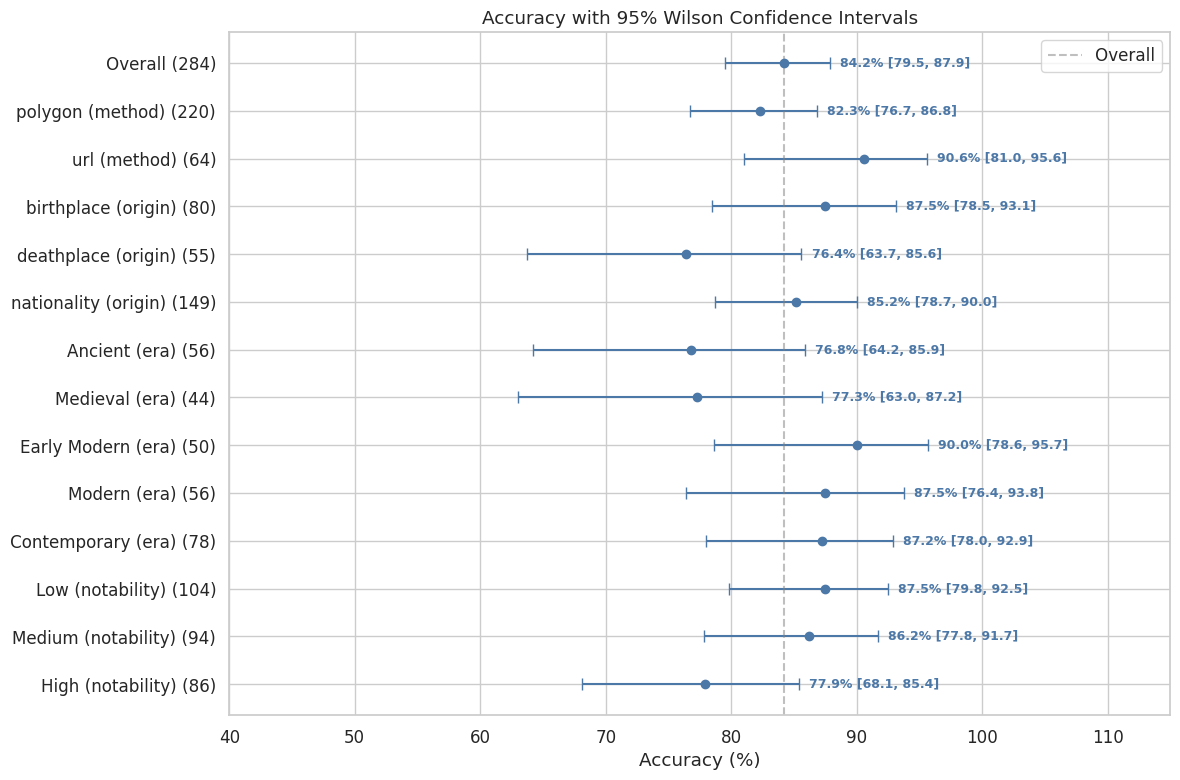

In [23]:
# Forest plot of accuracy with confidence intervals
fig, ax = plt.subplots(figsize=(12, 8))

ci_plot = ci_df.copy()

# Labels: "Overall", "polygon (method)", "birthplace (origin)", "Ancient (era)", "Low (notability)"
category_labels = {"Method": "method", "Origin": "origin", "Era": "era", "Notability": "notability"}
ci_plot["label"] = ci_plot.apply(
    lambda r: f"Overall ({r['n']})" if r["Category"] == "Overall"
    else f"{r['Group']} ({category_labels[r['Category']]}) ({r['n']})",
    axis=1
)
ci_plot = ci_plot.iloc[::-1]  # reverse for top-to-bottom reading

y_pos = range(len(ci_plot))
ax.errorbar(
    ci_plot["Accuracy (%)"],
    y_pos,
    xerr=[ci_plot["Accuracy (%)"] - ci_plot["95% CI lower"],
          ci_plot["95% CI upper"] - ci_plot["Accuracy (%)"]],
    fmt="o", color="#4C78A8", capsize=4, markersize=6
)

# Add blue text at the end of each interval: accuracy% [CI_lo, CI_hi]
for i, (_, row) in enumerate(ci_plot.iterrows()):
    ax.text(
        row["95% CI upper"] + 0.8, i,
        f"{row['Accuracy (%)']:.1f}% [{row['95% CI lower']:.1f}, {row['95% CI upper']:.1f}]",
        va="center", ha="left", fontsize=9, color="#4C78A8", fontweight="bold"
    )

ax.set_yticks(list(y_pos))
ax.set_yticklabels(ci_plot["label"])
ax.set_xlabel("Accuracy (%)")
ax.set_title("Accuracy with 95% Wilson Confidence Intervals")
ax.axvline(x=ci_df.loc[0, "Accuracy (%)"], color="gray", linestyle="--", alpha=0.5, label="Overall")
ax.legend()
ax.set_xlim(40, 115)

plt.tight_layout()
plt.show()

## 9. Unrated records analysis

In [24]:
unrated = df[df["rating"].isna()]
print(f"Unrated records: {len(unrated)} out of {len(df)} ({len(unrated)/len(df)*100:.1f}%)")
print()
print("Unrated by method:")
print(unrated["method_group"].value_counts())
print()
print("Unrated by origin:")
print(unrated["origin"].value_counts())
print()
# These are mostly url_fallback records — the fallback method has many unrated records
print("Note: Most unrated records come from the url_fallback method,")
print("which lacks impact dates and is harder to validate.")

Unrated records: 1 out of 285 (0.4%)

Unrated by method:
method_group
url    1
Name: count, dtype: int64

Unrated by origin:
origin
nationality    1
Name: count, dtype: int64

Note: Most unrated records come from the url_fallback method,
which lacks impact dates and is harder to validate.


## 10. Linkage rule breakdown — extrapolation to full database

Based on the linkage description:
- Total associations: 6,173,349 (47.5% of all individuals)
- Polygon-based: 76.2% of matches = 4,704,584
- URL-based: 23.8% of matches = 1,468,765
  - Of which nationality URL: 94.1% = 1,382,133

We extrapolate the annotation accuracy to estimate true positive counts.

In [25]:
# Known population sizes from the linkage description
total_associations = 6_173_349
polygon_total = 4_704_584  # 76.2%
url_total = 1_468_765  # 23.8%
url_nationality_total = 1_382_133  # 94.1% of URL

# Get accuracy per method from annotations
acc_polygon = method_acc.loc["polygon", "accuracy_%"] / 100 if "polygon" in method_acc.index else np.nan
acc_url = method_acc.loc["url", "accuracy_%"] / 100 if "url" in method_acc.index else np.nan

print("=== Extrapolation to full database ===")
print(f"\nPolygon accuracy (from {method_acc.loc['polygon', 'n']:.0f} annotations): {acc_polygon*100:.1f}%")
print(f"  -> Estimated correct polygon matches: {polygon_total * acc_polygon:,.0f} / {polygon_total:,}")
print(f"\nURL accuracy (from {method_acc.loc['url', 'n']:.0f} annotations): {acc_url*100:.1f}%")
print(f"  -> Estimated correct URL matches: {url_total * acc_url:,.0f} / {url_total:,}")
weighted = (polygon_total * acc_polygon + url_total * acc_url) / total_associations * 100
print(f"\nWeighted overall accuracy estimate: {weighted:.1f}%")
print(f"  -> Estimated correct total: "
      f"{polygon_total * acc_polygon + url_total * acc_url:,.0f} / {total_associations:,}")

=== Extrapolation to full database ===

Polygon accuracy (from 220 annotations): 82.3%
  -> Estimated correct polygon matches: 3,871,873 / 4,704,584

URL accuracy (from 64 annotations): 90.6%
  -> Estimated correct URL matches: 1,330,701 / 1,468,765

Weighted overall accuracy estimate: 84.3%
  -> Estimated correct total: 5,202,574 / 6,173,349


In [26]:
print("="*70)
print("ANNOTATION ANALYSIS SUMMARY")
print("="*70)
print(f"\nAnnotated sample: {len(df)} records")
print(f"Rated records:    {total_rated}")
print(f"Overall accuracy: {correct}/{total_rated} = {correct/total_rated*100:.1f}%")
print(f"\nBy method:")
for idx, row in method_acc.iterrows():
    print(f"  {idx:15s}: {row['accuracy_%']:5.1f}%  (n={row['n']:.0f})")
print(f"\nBy origin:")
for idx, row in origin_acc.iterrows():
    print(f"  {idx:15s}: {row['accuracy_%']:5.1f}%  (n={row['n']:.0f})")
print(f"\nBy era:")
for idx, row in era_acc.iterrows():
    print(f"  {idx:15s}: {row['accuracy_%']:5.1f}%  (n={row['n']:.0f})")
print(f"\nBy notability:")
for idx, row in notability_acc.iterrows():
    print(f"  {idx:15s}: {row['accuracy_%']:5.1f}%  (n={row['n']:.0f})")
print(f"\nBy region:")
for idx, row in region_acc.iterrows():
    print(f"  {idx:40s}: {row['accuracy_%']:5.1f}%  (n={row['n']:.0f})")

ANNOTATION ANALYSIS SUMMARY

Annotated sample: 285 records
Rated records:    284
Overall accuracy: 239/284 = 84.2%

By method:
  polygon        :  82.3%  (n=220)
  url            :  90.6%  (n=64)

By origin:
  birthplace     :  87.5%  (n=80)
  deathplace     :  76.4%  (n=55)
  nationality    :  85.2%  (n=149)

By era:
  Ancient        :  76.8%  (n=56)
  Medieval       :  77.3%  (n=44)
  Early Modern   :  90.0%  (n=50)
  Modern         :  87.5%  (n=56)
  Contemporary   :  87.2%  (n=78)

By notability:
  Low            :  87.5%  (n=104)
  Medium         :  86.2%  (n=94)
  High           :  77.9%  (n=86)

By region:
  Ancient Mediterranean                   :  87.5%  (n=16)
  Asia                                    :  84.3%  (n=70)
  Eastern Europe                          :  82.5%  (n=80)
  Latin America                           :  90.9%  (n=33)
  Middle-East and Africa (MENA)           :  78.6%  (n=28)
  North America                           : 100.0%  (n=9)
  Oceania                 

In [27]:
# Nationality-based URL matching accuracy
url_nat = rated[(rated["method_group"] == "url") & (rated["origin"] == "nationality")]
n_url_nat = len(url_nat)
correct_url_nat = int(url_nat["rating"].sum())
acc_url_nat = correct_url_nat / n_url_nat * 100

lo, hi = wilson_ci(correct_url_nat, n_url_nat)

print(f"Nationality-based URL matching accuracy: {acc_url_nat:.1f}% ({correct_url_nat}/{n_url_nat})")
print(f"95% Wilson CI: [{lo*100:.1f}%, {hi*100:.1f}%]")

Nationality-based URL matching accuracy: 100.0% (29/29)
95% Wilson CI: [88.3%, 100.0%]
